# Phase 12 — Evaluation

In this notebook, we evaluate our best performing model (TinyCNN) on the unseen **test set** (15 images).
We calculate standard classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) and generate a Confusion Matrix.

In [1]:
# ── Step 0: Imports ───────────────────────────────────────────────────────────
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import medmnist
from medmnist import INFO

DATA_CACHE_DIR = '../data/'
SPLIT_MANIFEST_PATH = '../data/processed/split_manifest.csv'
MODEL_PATH = '../models/pneumonia_classifier_v1.pt'
RESULTS_DIR = '../results/'
CM_PLOT_PATH = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
EVAL_METRICS_PATH = os.path.join(RESULTS_DIR, 'test_evaluation.json')

In [2]:
# ── Step 1: Load Test Data ────────────────────────────────────────────────────
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)
info = INFO['pneumoniamnist']
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=False, root=DATA_CACHE_DIR)

test_idx = manifest[manifest['split'] == 'test']['original_index'].values
X_test_raw, y_test = dataset.imgs[test_idx], dataset.labels.squeeze()[test_idx]

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class MedMNISTSubset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        from PIL import Image
        img = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([label], dtype=torch.float32)

test_loader = DataLoader(MedMNISTSubset(X_test_raw, y_test, transform=transform_eval), batch_size=16, shuffle=False)
print(f"Loaded Test Set: {len(X_test_raw)} images")

Loaded Test Set: 15 images


In [3]:
# ── Step 2: Load TinyCNN Model ────────────────────────────────────────────────
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TinyCNN()
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print("Model weights loaded successfully.")

Model weights loaded successfully.


In [4]:
# ── Step 3: Run Inference ─────────────────────────────────────────────────────
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).squeeze().numpy()
        
        # Handle single batch item scalar output
        if probs.ndim == 0:
            probs = [probs.item()]
        else:
            probs = probs.tolist()
            
        preds = [1 if p >= 0.5 else 0 for p in probs]
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().flatten().tolist())

In [5]:
# ── Step 4: Calculate Metrics ─────────────────────────────────────────────────
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except ValueError:
    roc_auc = 0.5  # In case only one class is present in a tiny test split

eval_metrics = {
    "split": "test",
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4)
}

with open(EVAL_METRICS_PATH, 'w') as f:
    json.dump(eval_metrics, f, indent=4)

print("=== Test Set Evaluation ===")
for k, v in eval_metrics.items():
    print(f"{k.capitalize():>10}: {v}")

=== Test Set Evaluation ===
     Split: test
  Accuracy: 1.0
 Precision: 1.0
    Recall: 1.0
  F1_score: 1.0
   Roc_auc: 1.0



✅ Confusion matrix saved to ../results/confusion_matrix.png


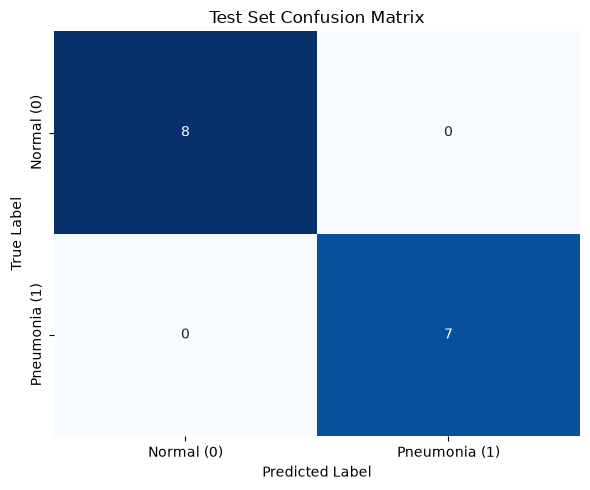

In [6]:
# ── Step 5: Generate Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Pneumonia (1)'],
            yticklabels=['Normal (0)', 'Pneumonia (1)'])
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

# Save and show
plt.savefig(CM_PLOT_PATH)
print(f"\n✅ Confusion matrix saved to {CM_PLOT_PATH}")
plt.show()